In [ ]:
from sam3.samgeo3 import SamGeo3
from typing import List
from sam3.samgeo3 import PredictionResult
from matplotlib import pyplot as plt

In [2]:
print("Initializing SamGeo3 with strict typing...")
sam = SamGeo3(model_id="data/sam3")

Initializing SamGeo3 with strict typing...


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

The OrderedVocab you are attempting to save contains holes for indices [1], your vocabulary could be corrupted !
The OrderedVocab you are attempting to save contains holes for indices [1], your vocabulary could be corrupted !


--- Example 1: Single Image Text ---


SAM3 Text Batch: 100%|██████████| 1/1 [00:02<00:00,  2.90s/batch]


Generated 97 masks for 'house'.


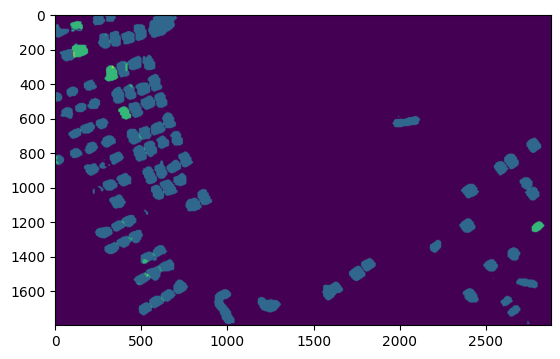

In [4]:
print("--- Example 1: Single Image Text ---")
img_url_1 = "data/example/netivot1.tif"
sam.set_image(img_url_1)
sam.generate_masks(prompt="house")
if sam.masks:
    print(f"Generated {len(sam.masks)} masks for 'house'.")
plt.imshow(sum(sam.masks))

--- Example 2: Batch Text Prediction ---


SAM3 Text Batch: 100%|██████████| 1/1 [00:04<00:00,  4.98s/batch]


Image 0 (road): 26 masks found.
Image 1 (road): 25 masks found.


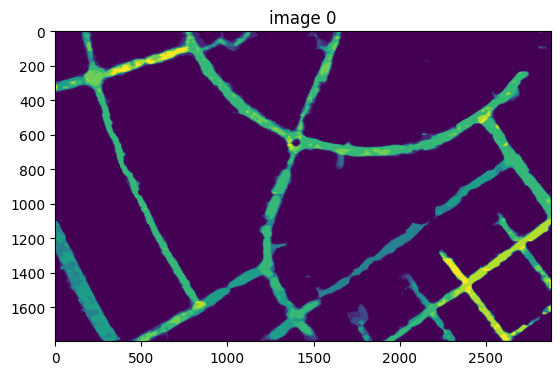

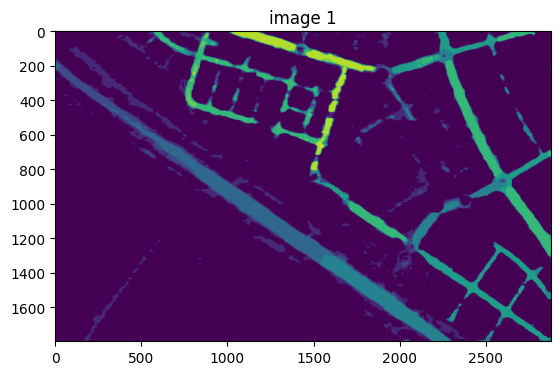

In [4]:
print("--- Example 2: Batch Text Prediction ---")
img_url_1 = "data/example/netivot1.tif"
img_url_2 = "data/example/netivot2.tif"
images: List[str] = [img_url_1, img_url_2]
prompts: List[str] = ["road"]*len(images)
batch_results: List[PredictionResult] = sam.predict_batch_text(
    images, prompts, batch_size=2,clear_model_weights=True  # type: ignore - pylance is wrong
)
for idx, res in enumerate(batch_results):
    print(f"Image {idx} ({prompts[idx]}): {len(res['masks'])} masks found.")

for i,results in enumerate(batch_results):
    plt.figure()
    plt.title(f"image {i}")
    plt.imshow(sum(results['masks']))

In [6]:
batch_results[0]

{'masks': [array([[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]], shape=(1798, 2878)),
  array([[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]], shape=(1798, 2878)),
  array([[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]], shape=(1798, 2878)),
  array([[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]], shape=(1798, 2878)),
  array([[0, 0, 0, ..., 0, 0, 0

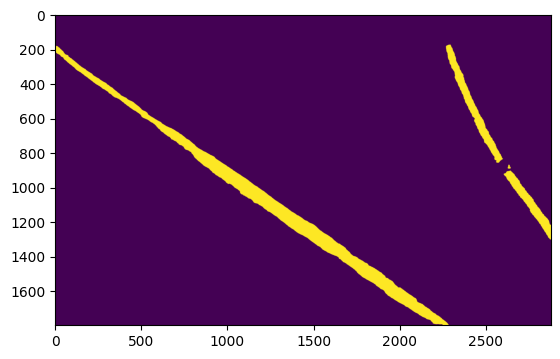